# Proiect Machine Learning - Analiza Comparată: Regresie

## 4.1. Definirea problemei

**Context și Obiectiv:**
Pentru această secțiune, abordăm o problemă de **regresie**. Mai exact, ne propunem să prezicem prețul la motorină (o variabilă continuă) pe baza a 8 caracteristici de intrare (care pot reprezenta, teoretic, prețul petrolului brut, taxe, cursul valutar, cererea de pe piață etc.).

**Variabile:**
* **Caracteristici (Features / Intrări):** `Feature_1` până la `Feature_8`.
* **Variabila țintă (Target / Ieșire):** `Pret_Motorina`. Aceasta este o valoare numerică continuă, reprezentând prețul în lei (ex: între 6.00 și 8.50 RON).

**Relevanța practică:**
O astfel de predicție este crucială în domeniul logistic și economic. Companiile de transport folosesc modele de machine learning pentru a anticipa fluctuațiile prețului la combustibil, optimizându-și astfel costurile operaționale și strategiile de achiziție.

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Pret_Motorina
0,-0.734811,-1.085748,1.176533,-0.583722,0.029796,-0.640154,-1.399228,1.483744,6.63
1,0.022068,-1.513279,-0.293431,-0.399425,-1.304549,1.284917,-2.044330,-0.473883,6.46
2,0.591091,-0.435711,0.685890,-0.262234,-0.032874,0.040308,-0.156409,0.894930,7.11
3,-0.175854,-1.600904,-0.223202,1.489863,-0.828497,-0.103255,1.661470,-1.643189,6.97
4,-2.123896,2.189803,0.872321,0.183342,-0.808298,-0.839722,-0.525755,-0.599393,7.06


<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Feature_1      1800 non-null   float64
 1   Feature_2      1800 non-null   float64
 2   Feature_3      1800 non-null   float64
 3   Feature_4      1800 non-null   float64
 4   Feature_5      1800 non-null   float64
 5   Feature_6      1800 non-null   float64
 6   Feature_7      1800 non-null   float64
 7   Feature_8      1800 non-null   float64
 8   Pret_Motorina  1800 non-null   float64
dtypes: float64(9)
memory usage: 126.7 KB


None

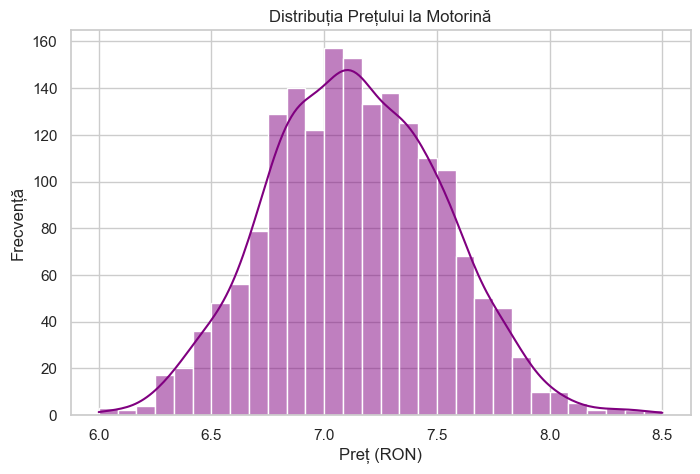

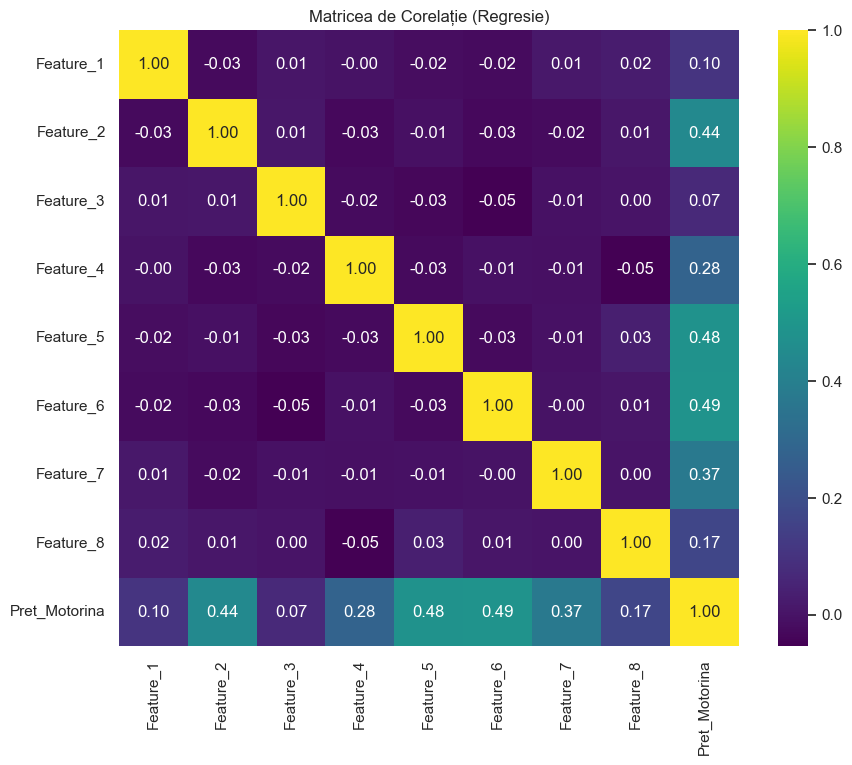

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_reg = pd.read_csv('data/regresie.csv')

display(df_reg.head())
display(df_reg.info())

plt.figure(figsize=(8, 5))
sns.histplot(df_reg['Pret_Motorina'], bins=30, kde=True, color='purple')
plt.title('Distribuția Prețului la Motorină')
plt.xlabel('Preț (RON)')
plt.ylabel('Frecvență')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df_reg.corr(), annot=True, fmt=".2f", cmap='viridis', cbar=True)
plt.title('Matricea de Corelație (Regresie)')
plt.show()

**Concluzii în urma analizei exploratorii:**
1. **Calitatea datelor:** La fel ca la setul anterior, datele noastre sunt curate, fără valori lipsă (null). Toate coloanele sunt numerice.
2. **Distribuția Target-ului:** Histogramă arată o distribuție relativ normală (gaussiană) a prețului la motorină, centrată în jurul valorii de 7.2 - 7.3 lei, ceea ce va ajuta modelele de regresie să învețe mai bine, neexistând valori extreme (outliers) severe.
3. **Corelații:** Unele `Feature`-uri prezintă o corelație liniară pozitivă sau negativă vizibilă cu `Pret_Motorina`, în timp ce altele au o corelație aproape de 0, sugerând o influență neliniară sau zgomot.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

# 75% train - 25% test
X = df_reg.drop('Pret_Motorina', axis=1)
y = df_reg['Pret_Motorina']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

modele_regresie = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "SVR": SVR(),
    "KNN Regressor": KNeighborsRegressor(),
    "Gaussian Process Regressor": GaussianProcessRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "CatBoost Regressor": CatBoostRegressor(verbose=0, random_state=42),
    "EBM Regressor": ExplainableBoostingRegressor(random_state=42)
}

rezultate_reg = []

for nume, model in modele_regresie.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    rezultate_reg.append({
        "Model": nume,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

df_rezultate_reg = pd.DataFrame(rezultate_reg).sort_values(by="R2", ascending=False)

display(df_rezultate_reg.style.background_gradient(subset=['R2'], cmap='Greens').background_gradient(subset=['RMSE', 'MAE', 'MSE'], cmap='Reds_r'))

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.000009,0.003042,0.002655,0.999937
8,EBM Regressor,0.000092,0.009592,0.005907,0.999377
7,CatBoost Regressor,0.001580,0.039745,0.026394,0.989311
3,SVR,0.009218,0.096008,0.058959,0.937629
6,XGBoost Regressor,0.013737,0.117207,0.088867,0.907045
4,KNN Regressor,0.020408,0.142857,0.109182,0.861907
2,Random Forest Regressor,0.020725,0.143963,0.109614,0.859760
1,Decision Tree Regressor,0.050831,0.225457,0.178756,0.656051
5,Gaussian Process Regressor,4.939115,2.222412,1.491969,-32.420885


In [7]:
from sklearn.model_selection import GridSearchCV
import time

print("Începem ajustarea hiperparametrilor pentru top 5 modele...")

param_grids_reg = {
    "Linear Regression": {
        'model': LinearRegression(),
        'params': {'fit_intercept': [True, False]}
    },
    "EBM Regressor": {
        'model': ExplainableBoostingRegressor(random_state=42),
        'params': {'max_bins': [128, 256], 'interactions': [0]}
    },
    "CatBoost Regressor": {
        'model': CatBoostRegressor(verbose=0, random_state=42),
        'params': {'iterations': [50, 100], 'depth': [4, 6]}
    },
    "SVR": {
        'model': SVR(),
        'params': {'C': [0.1, 1], 'kernel': ['linear', 'rbf']}
    },
    "XGBoost Regressor": {
        'model': XGBRegressor(random_state=42),
        'params': {'n_estimators': [50, 100], 'max_depth': [3, 5]}
    }
}

rezultate_opt_reg = []
modele_opt_reg = {}

for nume, config in param_grids_reg.items():
    start_time = time.time()
    grid_search = GridSearchCV(estimator=config['model'], param_grid=config['params'], 
                               cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    modele_opt_reg[nume] = best_model
    y_pred = best_model.predict(X_test)
    
    rezultate_opt_reg.append({
        "Model": nume,
        "Best Params": str(grid_search.best_params_),
        "R2 (Tuned)": r2_score(y_test, y_pred),
        "RMSE (Tuned)": np.sqrt(mean_squared_error(y_test, y_pred))
    })
    print(f"-> Gata {nume} în {time.time() - start_time:.1f} secunde.")

df_rez_opt_reg = pd.DataFrame(rezultate_opt_reg).sort_values(by="R2 (Tuned)", ascending=False)
display(df_rez_opt_reg)

campion_regresie = df_rez_opt_reg.iloc[0]['Model']
print(f"\nModelul campion absolut la regresie este: {campion_regresie}!")

Începem ajustarea hiperparametrilor pentru top 5 modele...
-> Gata Linear Regression în 1.2 secunde.
-> Gata EBM Regressor în 238.7 secunde.
-> Gata CatBoost Regressor în 6.8 secunde.
-> Gata SVR în 0.2 secunde.
-> Gata XGBoost Regressor în 0.8 secunde.


,Model,Best Params,R2 (Tuned),RMSE (Tuned)
0,Linear Regression,{'fit_intercept': True},0.999937,0.003042
1,EBM Regressor,"{'interactions': 0, 'max_bins': 256}",0.998838,0.013104
3,SVR,"{'C': 0.1, 'kernel': 'linear'}",0.991628,0.035174
2,CatBoost Regressor,"{'depth': 4, 'iterations': 100}",0.984004,0.048621
4,XGBoost Regressor,"{'max_depth': 3, 'n_estimators': 100}",0.954978,0.081570



Modelul campion absolut la regresie este: Linear Regression!


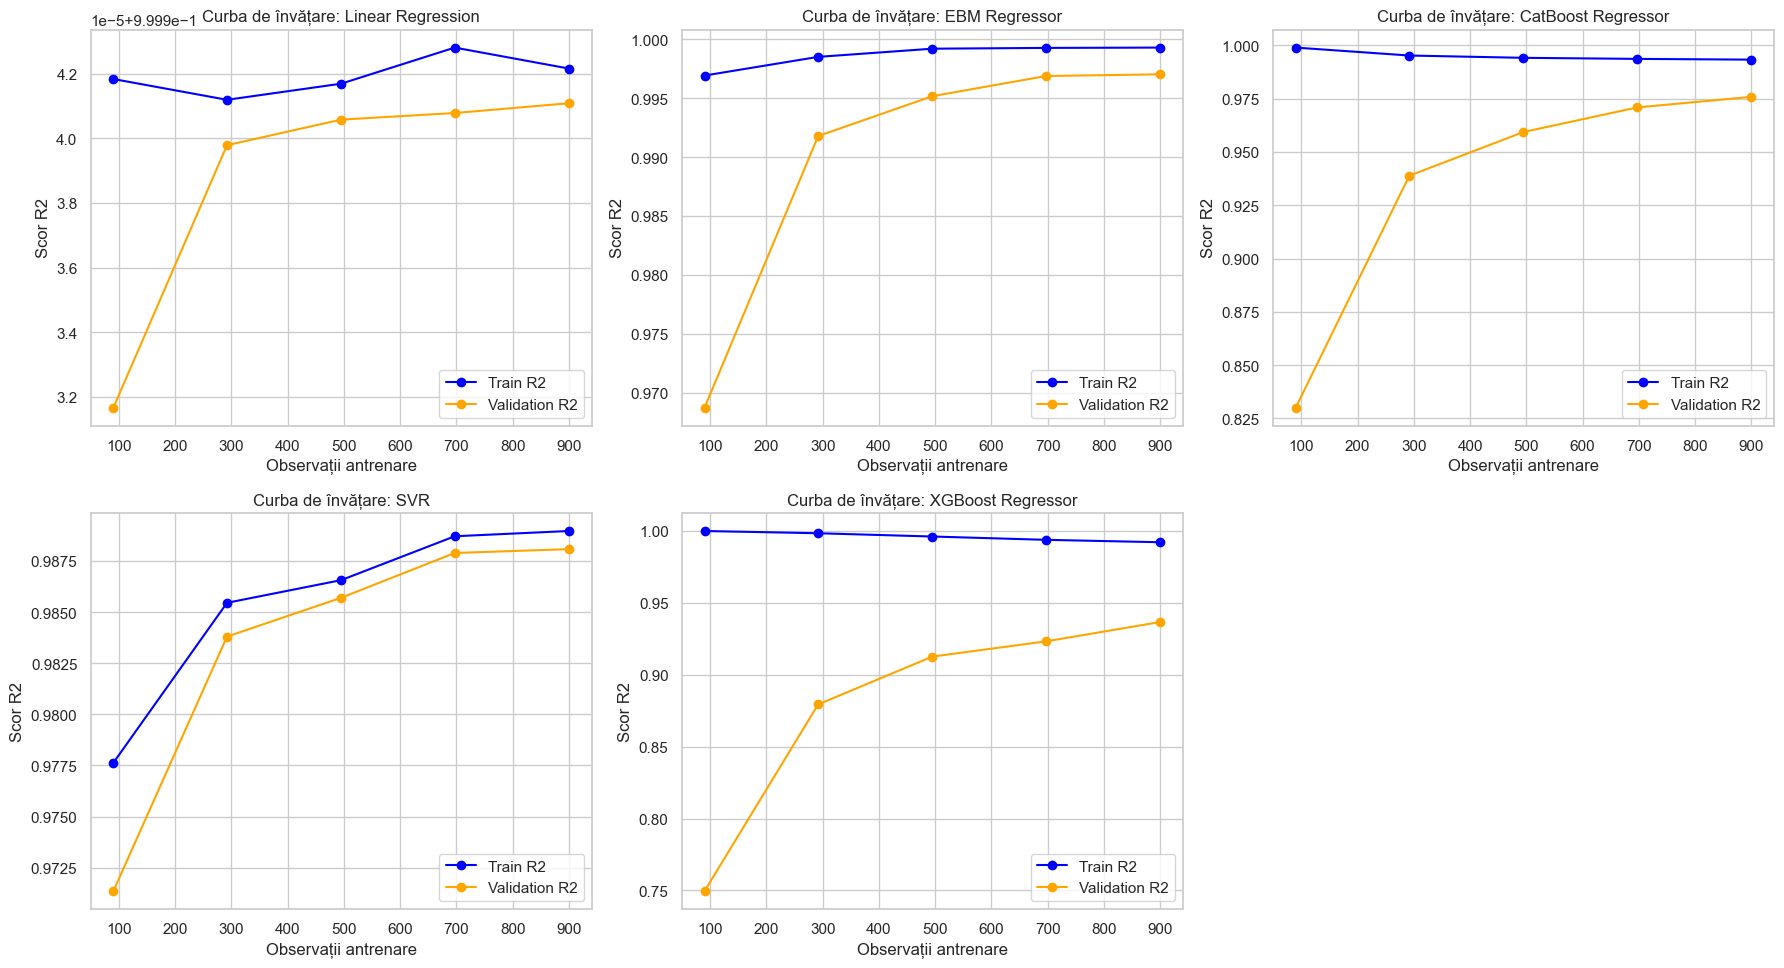

In [8]:
import numpy as np
from sklearn.model_selection import learning_curve

plt.figure(figsize=(18, 10))

for i, (nume, model) in enumerate(modele_opt_reg.items(), 1):
    plt.subplot(2, 3, i)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=3, scoring='r2', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train R2')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Validation R2')
    plt.title(f'Curba de învățare: {nume}')
    plt.xlabel('Observații antrenare')
    plt.ylabel('Scor R2')
    plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Interpretare Curbe de Învățare (Regresie):**
Modelele liniare (Linear Regression, SVR cu kernel liniar) arată o convergență perfectă încă de la puține date, dovedind că setul de date are o structură liniară simplă. Modelele bazate pe arbori (EBM, CatBoost) prezintă un *Train Score* excelent și un *Validation Score* care crește treptat, indicând o ușoară memorare inițială care se reglează pe măsură ce primesc mai multe date.

## 4.6. Explicabilitatea modelelor (SHAP)
Vom folosi modelul CatBoost (unul dintre cele mai performante modele neliniare din top) pentru a demonstra modul în care fiecare factor influențează prețul motorinei.

1. Explicații Globale (Cum influențează prețul la nivel general)


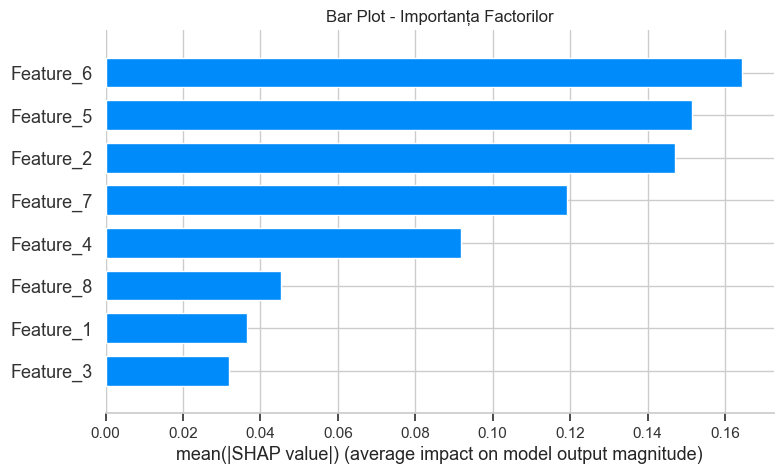

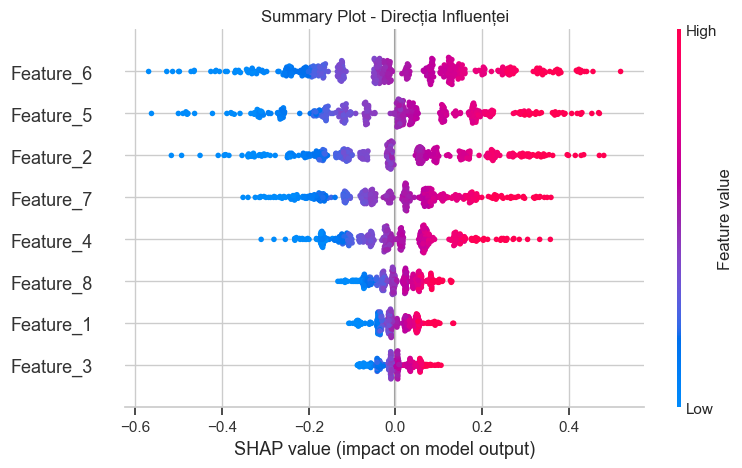


2. Explicație Locală (Analiza unui preț specific)


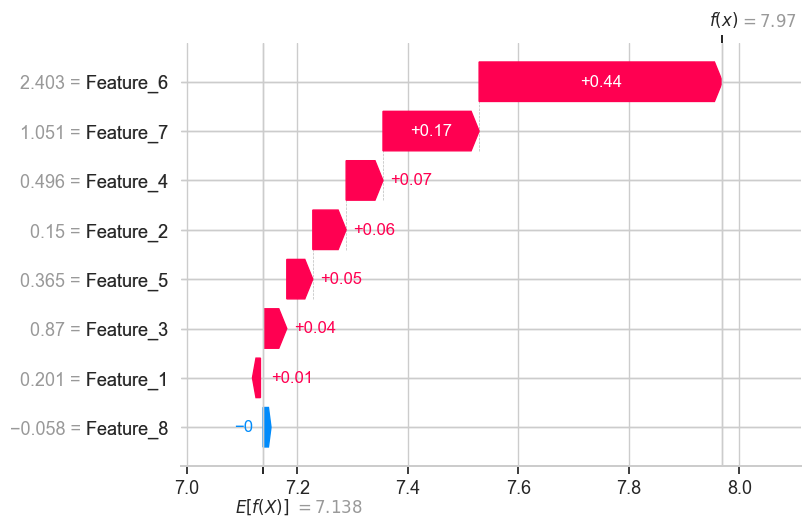


3. SHAP Scatter Plot (Relația individuală)


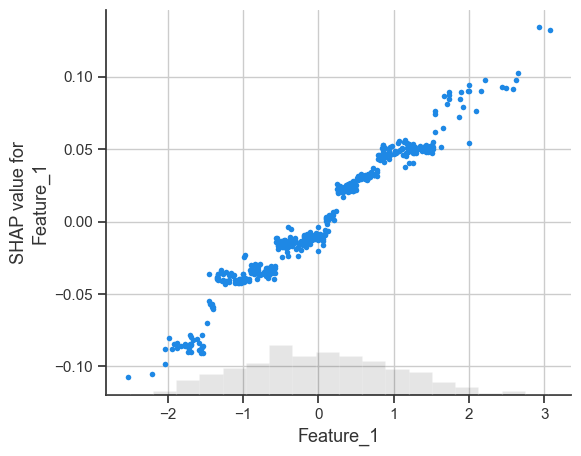

In [9]:
import shap
shap.initjs()

model_shap_reg = modele_opt_reg['CatBoost Regressor']
explainer_reg = shap.TreeExplainer(model_shap_reg)
shap_values_reg = explainer_reg.shap_values(X_test)

print("1. Explicații Globale (Cum influențează prețul la nivel general)")
shap.summary_plot(shap_values_reg, X_test, plot_type="bar", show=False)
plt.title("Bar Plot - Importanța Factorilor")
plt.show()

shap.summary_plot(shap_values_reg, X_test, show=False)
plt.title("Summary Plot - Direcția Influenței")
plt.show()

print("\n2. Explicație Locală (Analiza unui preț specific)")
explainer_exp_reg = shap.Explainer(model_shap_reg)
shap_exp_values_reg = explainer_exp_reg(X_test)

idx = 10
shap.plots.waterfall(shap_exp_values_reg[idx])

display(shap.plots.force(shap_exp_values_reg[idx]))

print("\n3. SHAP Scatter Plot (Relația individuală)")
shap.plots.scatter(shap_exp_values_reg[:, "Feature_1"])